In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [2]:
vis_epoch_lims=(-1.0, 2.0)
mot_epoch_lims=(-1.0, 1.5)
vis_plot_lims=(-0.25, 1.85)
mot_plot_lims=(-0.7, 1.2)

In [6]:
# Set global matplotlib parameters
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

# Define color palettes
colors0 = sns.color_palette("magma", n_colors=6)
colors1 = sns.color_palette("mako_r", n_colors=10)
pastel = sns.color_palette("Pastel1", n_colors=6)
adapt1 = sns.color_palette("Set1", n_colors=9)
adapt2 = sns.color_palette("Accent", n_colors=8)
colors4 = sns.color_palette("magma_r", n_colors=4)
colors5 = sns.color_palette("mako_r", n_colors=4)

# 
palette0 = sns.color_palette("magma_r", 3)
palette1 = sns.color_palette("mako_r", 3)

colors2 = [pastel[0], pastel[3], adapt2[5]]
colors3 = [pastel[1], pastel[2], colors5[2]]
colors_implicit = [pastel[0], adapt2[5], pastel[3]]  # Baseline, Washout, Adaptation
colors_explicit = [pastel[1], colors5[2], pastel[2]]  # Baseline, Washout, Adaptation
colorbl = [adapt1[4], colors1[2]]

# Define plot limits and proportional widths
plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
durations = {k: plot_lims[k][1] - plot_lims[k][0] for k in ['vis', 'mot']}
total_width = durations['vis'] + durations['mot']
width_ratios = [durations['vis'] / total_width, durations['mot'] / total_width]

In [7]:
def plot_var_results(var_name, disp_name, pc, use_next_trial=True, save_to_figures=False):
    """
    Plot burst rate results from R analysis pipeline.
    
    Parameters:
    -----------
    var_name : str
        Variable name (e.g., 'reach_vis_abs_err', 'reach_rt')
    disp_name : str
        Display name for plot labels
    pc : int
        Principal component number (7-10)
    use_next_trial : bool
        Whether to plot next_trial results (True) or current trial (False)
    save_to_figures : bool
        Whether to save to figures directory with figure7c naming (True) or output directory (False)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    
    # File naming based on R code
    if use_next_trial:
        burst_suffix = f"burst_rate_{var_name}_next_trial"
        window_suffix = f"{var_name}_next_trial_windows"
    else:
        burst_suffix = f"burst_rate_{var_name}"
        window_suffix = f"{var_name}_windows"
    
    # Read burst rate trends
    vis_df = pd.read_csv(f"output/PC_{pc}_vis_{burst_suffix}.csv")
    mot_df = pd.read_csv(f"output/PC_{pc}_mot_{burst_suffix}.csv")
    
    # Read window statistics
    try:
        vis_stats = pd.read_csv(f"output/PC_{pc}_vis_{window_suffix}.csv")
    except FileNotFoundError:
        vis_stats = pd.DataFrame({'pc': [], 'quartile': [], 'start': []})
        print(f"Warning: No VIS windows file found for PC {pc}")
    
    try:
        mot_stats = pd.read_csv(f"output/PC_{pc}_mot_{window_suffix}.csv")
    except FileNotFoundError:
        mot_stats = pd.DataFrame({'pc': [], 'quartile': [], 'start': []})
        print(f"Warning: No MOT windows file found for PC {pc}")
    
    # Color scheme
    group_colors = {"Implicit": palette0[1], "Explicit": palette1[2]}    
    
    # Plot limits - adjust these to your data ranges
    vis_plot_lims = (-0.5, 1.0)
    mot_plot_lims = (-0.5, 1.5)
    plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
    width_ratios = [1, 1]
    
    quartiles = [1, 2, 3, 4]
    
    for q in quartiles:
        vis_subset = vis_df[(vis_df.pc == pc) & (vis_df.quartile == q)].copy()
        mot_subset = mot_df[(mot_df.pc == pc) & (mot_df.quartile == q)].copy()
        
        # Check if we have data for this quartile
        if vis_subset.empty and mot_subset.empty:
            print(f"Warning: No data for PC {pc}, Q{q}")
            continue
        
        # Convert to milliseconds for RT and duration
        if 'dur' in var_name or 'rt' in var_name:
            vis_subset['estimate'] = vis_subset['estimate'] * 1000
            mot_subset['estimate'] = mot_subset['estimate'] * 1000
            vis_subset['SE'] = vis_subset['SE'] * 1000
            mot_subset['SE'] = mot_subset['SE'] * 1000
        
        # Remove non-finite values
        vis_subset = vis_subset[np.isfinite(vis_subset["SE"])]
        mot_subset = mot_subset[np.isfinite(mot_subset["SE"])]
        
        # Calculate y-axis limits with space for significance markers
        y_all = pd.concat([vis_subset["estimate"], mot_subset["estimate"]])
        if y_all.empty:
            print(f"Warning: No valid data for PC {pc}, Q{q} after filtering")
            continue
            
        y_min, y_max = y_all.min(), y_all.max()
        y_span = y_max - y_min
        if y_span == 0:
            y_span = abs(y_max) if y_max != 0 else 1
        y_offset_unit = 0.2 * y_span
        
        # Y positions for significance markers
        y_exp_marker = y_max + y_offset_unit
        y_imp_marker = y_exp_marker + y_offset_unit
        y_int_marker = y_imp_marker + y_offset_unit
        
        fig = plt.figure(figsize=(10, 4))
        gs = fig.add_gridspec(1, 2, width_ratios=width_ratios)
        group_list = ["Implicit", "Explicit"]
        common_ylim = (y_min - y_offset_unit, y_int_marker + y_offset_unit)
        
        for idx, (subset, limits, title, stats_df) in enumerate([
            (vis_subset, plot_lims['vis'], "vis", vis_stats),
            (mot_subset, plot_lims['mot'], "mot", mot_stats)
        ]):
            ax = fig.add_subplot(gs[idx])
            
            if subset.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                       transform=ax.transAxes)
                ax.set_xlim(limits)
                ax.set_ylim(common_ylim)
                ax.set_title(f"{title.upper()}")
                continue
            
            # Filter stats for current PC, quartile, and time range
            q_stats_df = stats_df[
                (stats_df['pc'] == pc) & 
                (stats_df['quartile'] == q) & 
                (stats_df['start'] > limits[0])
            ].copy()
            
            # Get time points for significance markers
            time = None
            
            # Plot each group's trend line
            for group in group_list:
                df_group = subset[
                    (subset['group'] == group) & 
                    (np.isfinite(subset['SE']))
                ].copy()
                
                if df_group.empty:
                    continue
                
                time = df_group['time'].astype(float).values
                est = df_group['estimate'].astype(float).values
                se = df_group['SE'].astype(float).values
                
                ax.plot(time, est, label=group, color=group_colors[group], linewidth=2)
                ax.fill_between(time, est - se, est + se, alpha=0.2, color=group_colors[group])
            
            if time is None:
                ax.set_xlim(limits)
                ax.set_ylim(common_ylim)
                ax.set_title(f"{title.upper()}")
                continue
                
            # Track which timepoints have interaction effects
            interaction_idxs = np.zeros(time.shape, dtype=bool)
            
            # Plot interaction effects first
            for index, q_stats_row in q_stats_df.iterrows():
                if q_stats_row['factor'] != 'group:mean_burst_count':
                    continue
                
                start = q_stats_row['start']
                end = q_stats_row['end']
                chi_sq = q_stats_row['chi_sq']
                dof = q_stats_row['df']
                p_val = q_stats_row['p_val']
                exp_onesamp_z = q_stats_row['explicit_onesamp_z']
                exp_onesamp_p = q_stats_row['explicit_onesamp_p']
                imp_onesamp_z = q_stats_row['implicit_onesamp_z']
                imp_onesamp_p = q_stats_row['implicit_onesamp_p']
                explicit_implicit_z = q_stats_row['explicit_implicit_z']
                explicit_implicit_p = q_stats_row['explicit_implicit_p']
                
                print(f'\n{title.upper()} PC{pc} Q{q}: group:mean_burst_count [{start:.2f}, {end:.2f}]s')
                print(f'  χ²({dof:.0f}) = {chi_sq:.2f}, p = {p_val:.4f}')
                print(f'  Explicit:  z = {exp_onesamp_z:6.2f}, p = {exp_onesamp_p:.4f}')
                print(f'  Implicit:  z = {imp_onesamp_z:6.2f}, p = {imp_onesamp_p:.4f}')
                print(f'  Exp - Imp: z = {explicit_implicit_z:6.2f}, p = {explicit_implicit_p:.4f}')
                
                t_idx = np.where((time >= start) & (time <= end))[0]
                
                # Mark significant effects
                if exp_onesamp_p < 0.05:
                    ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                              color=group_colors['Explicit'], marker=".", s=100, zorder=10)
                
                if imp_onesamp_p < 0.05:
                    ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                              color=group_colors['Implicit'], marker=".", s=100, zorder=10)
                
                if explicit_implicit_p < 0.05:
                    ax.scatter(time[t_idx], [y_int_marker] * len(t_idx),
                              color='red', marker=".", s=100, zorder=10)
                
                interaction_idxs[t_idx] = True
            
            # Plot main effects (only where no interaction)
            for index, q_stats_row in q_stats_df.iterrows():
                if q_stats_row['factor'] != 'mean_burst_count':
                    continue
                
                start = q_stats_row['start']
                end = q_stats_row['end']
                chi_sq = q_stats_row['chi_sq']
                dof = q_stats_row['df']
                p_val = q_stats_row['p_val']
                
                print(f'\n{title.upper()} PC{pc} Q{q}: mean_burst_count [{start:.2f}, {end:.2f}]s')
                print(f'  χ²({dof:.0f}) = {chi_sq:.2f}, p = {p_val:.4f}')
                
                t_idx = np.where((time >= start) & (time <= end) & (~interaction_idxs))[0]
                
                if len(t_idx) > 0:
                    # Mark both groups for main effect
                    ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                              color=group_colors['Explicit'], marker=".", s=100, zorder=10)
                    ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                              color=group_colors['Implicit'], marker=".", s=100, zorder=10)
            
            # Formatting
            ax.axhline(0, linestyle="--", color="black", linewidth=1)
            ax.set_ylim(*common_ylim)
            ax.set_title(f"{title.upper()}")
            ax.set_xlabel("Time (s)")
            
            if idx == 0:
                ylabel = f"{disp_name} effect (ms)" if ('dur' in var_name or 'rt' in var_name) else f"{disp_name} effect (°)"
                ax.set_ylabel(ylabel)
            else:
                ax.set_yticklabels([])
            
            ax.set_xlim(limits)
        
        # Add legend
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper right')
        
        # Title
        trial_type = "Next Trial" if use_next_trial else "Current Trial"
        fig.suptitle(f"{disp_name} - PC {pc}, Q{q} ({trial_type})")
        
        plt.tight_layout()
        
        # Save figure
        if save_to_figures:
            # Save to figures directory with figure7c naming convention
            fig_dir = '/home/qmoreau/explicit_implicit_bursts/figures/'
            os.makedirs(fig_dir, exist_ok=True)
            
            # Create filename: figure7c_PCXX_QT_XX_var.pdf
            trial_suffix = "_next" if use_next_trial else ""
            filename = f'figure7c_PC{pc:02d}_QT_{q:02d}_{var_name}{trial_suffix}.pdf'
            save_path = os.path.join(fig_dir, filename)
            
            plt.savefig(save_path, bbox_inches='tight')
            print(f"Saved to: {save_path}")
        else:
            # Save to output directory (original behavior)
            os.makedirs('./output/burst_behav_results', exist_ok=True)
            save_suffix = f"{var_name}_next" if use_next_trial else var_name
            plt.savefig(f'./output/burst_behav_results/PC{pc}_Q{q}_{save_suffix}.pdf', bbox_inches='tight')
            plt.savefig(f'./output/burst_behav_results/PC{pc}_Q{q}_{save_suffix}.png', dpi=300, bbox_inches='tight')
        
        plt.show()
        plt.close()


# Batch plotting function
def plot_all_results(save_to_figures=False):
    """
    Plot all available results
    
    Parameters:
    -----------
    save_to_figures : bool
        Whether to save to figures directory with figure7c naming (True) or output directory (False)
    """
    variables = {
        'reach_vis_abs_err': 'Reach Error',
        'reach_rt': 'Reaction Time'
    }
    
    pcs = [7, 8, 9, 10]
    
    for var_name, disp_name in variables.items():
        print(f"\n{'='*60}")
        print(f"Processing: {disp_name} ({var_name})")
        print(f"{'='*60}")
        
        for pc in pcs:
            print(f"\n--- PC {pc} ---")
            
            try:
                # Plot next trial effects
                print("\nNext Trial Analysis:")
                plot_var_results(var_name, disp_name, pc, use_next_trial=True, save_to_figures=save_to_figures)
            except FileNotFoundError as e:
                print(f"Skipping PC{pc} next_trial: {e}")
            
            try:
                # Plot current trial effects
                print("\nCurrent Trial Analysis:")
                plot_var_results(var_name, disp_name, pc, use_next_trial=False, save_to_figures=save_to_figures)
            except FileNotFoundError as e:
                print(f"Skipping PC{pc} current_trial: {e}")


VIS PC8 Q1: mean_burst_count [1.32, 1.73]s
  χ²(1) = 5.41, p = 0.0200

MOT PC8 Q1: group:mean_burst_count [0.23, 0.65]s
  χ²(1) = 7.62, p = 0.0058
  Explicit:  z =   4.18, p = 0.0000
  Implicit:  z =   0.84, p = 0.4035
  Exp - Imp: z =   2.76, p = 0.0058
Saved to: /home/qmoreau/explicit_implicit_bursts/figures/figure7c_PC08_QT_01_reach_vis_abs_err.pdf


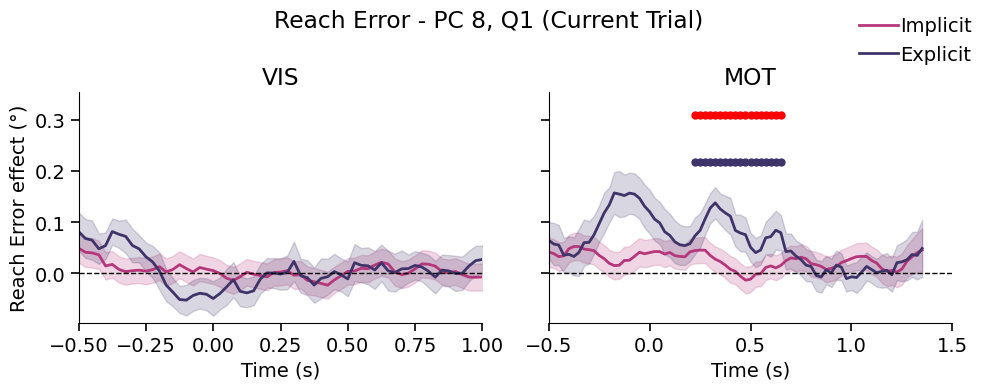


MOT PC8 Q2: group:mean_burst_count [0.05, 0.82]s
  χ²(1) = 4.15, p = 0.0416
  Explicit:  z =   4.70, p = 0.0000
  Implicit:  z =   4.48, p = 0.0000
  Exp - Imp: z =   2.04, p = 0.0416

MOT PC8 Q2: mean_burst_count [-0.30, 1.35]s
  χ²(1) = 56.49, p = 0.0000
Saved to: /home/qmoreau/explicit_implicit_bursts/figures/figure7c_PC08_QT_02_reach_vis_abs_err.pdf


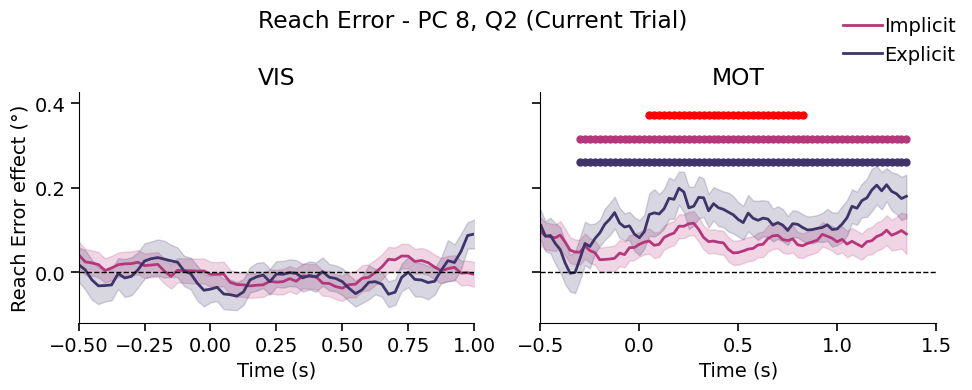


MOT PC8 Q3: mean_burst_count [0.62, 1.35]s
  χ²(1) = 9.14, p = 0.0025
Saved to: /home/qmoreau/explicit_implicit_bursts/figures/figure7c_PC08_QT_03_reach_vis_abs_err.pdf


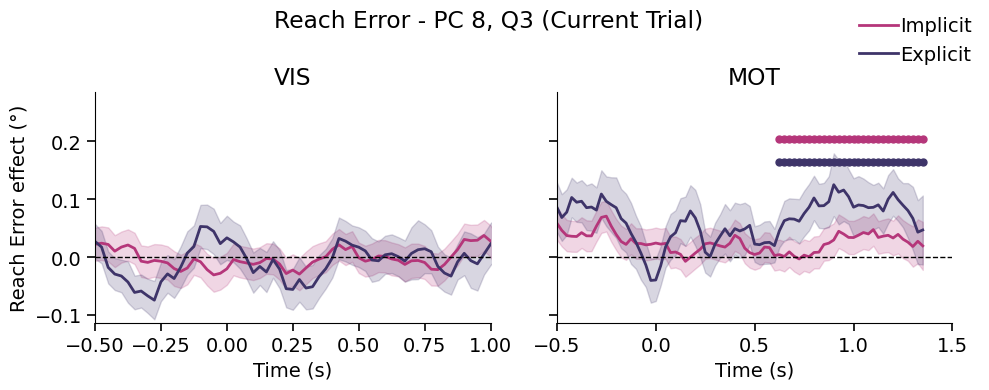


MOT PC8 Q4: group:mean_burst_count [-0.17, 1.32]s
  χ²(1) = 6.44, p = 0.0111
  Explicit:  z =  -5.85, p = 0.0000
  Implicit:  z =  -3.50, p = 0.0005
  Exp - Imp: z =  -2.54, p = 0.0111

MOT PC8 Q4: mean_burst_count [-0.17, 1.35]s
  χ²(1) = 47.74, p = 0.0000
Saved to: /home/qmoreau/explicit_implicit_bursts/figures/figure7c_PC08_QT_04_reach_vis_abs_err.pdf


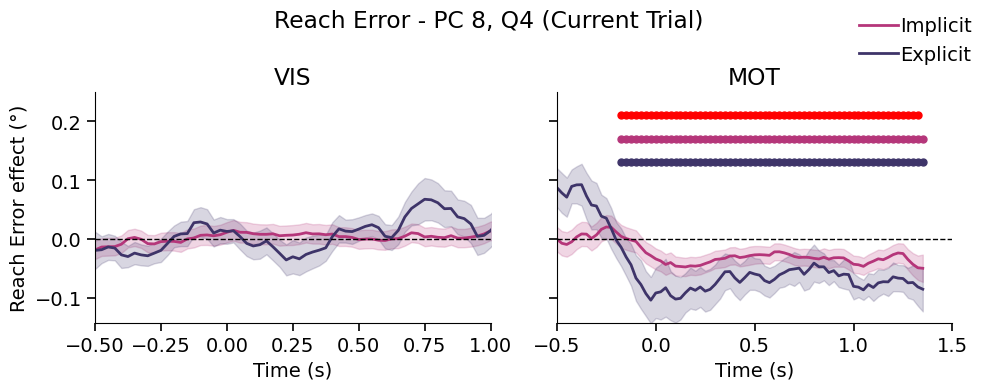

In [8]:
plot_var_results('reach_vis_abs_err', 'Reach Error', pc=8, use_next_trial=False, save_to_figures=True)

UnboundLocalError: cannot access local variable 'time' where it is not associated with a value

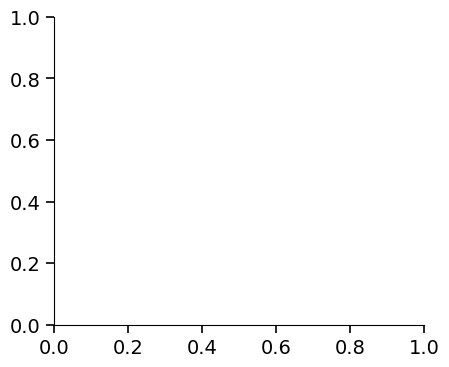

In [7]:
plot_var_results('reach_vis_abs_err', '|reach error|')

In [ ]:
# plot_var_results('aim_vis_abs_err_next_trial', 'next |aim error|')

In [ ]:
# plot_var_results('aim_vis_abs_err', '|aim error|')

In [ ]:
# plot_var_results('reach_rt_next_trial', 'next trial reach RT')

In [ ]:
# plot_var_results('reach_rt', 'reach RT')

In [ ]:
# plot_var_results('reach_dur_next_trial', 'next trial reach duration')

In [ ]:
# plot_var_results('reach_dur', 'reach duration')

In [8]:
def plot_all_vars_per_quartile(var_disp_list):
    group_colors = {"Implicit": colorbl[0], "Explicit": colorbl[1]}
    pcs = [7]
    quartiles = [1, 2, 3, 4]
    plot_lims = {'vis': vis_plot_lims, 'mot': mot_plot_lims}
    min_cluster_size = 15
    full_width_ratios = width_ratios * 2  # visual, motor × current, next

    current_vars = [(v, d) for v, d in var_disp_list if "next" not in v]
    next_vars = [(v, d) for v, d in var_disp_list if "next" in v]
    assert len(current_vars) == len(next_vars), "Mismatched number of current and next trial variables"

    for pc in pcs:
        for q in quartiles:
            fig, axes = plt.subplots(len(current_vars), 4, figsize=(16, 4 * len(current_vars)),
                                     gridspec_kw={'width_ratios': full_width_ratios})
            if len(current_vars) == 1:
                axes = np.expand_dims(axes, 0)

            for row_idx, ((curr_var, curr_disp), (next_var, next_disp)) in enumerate(zip(current_vars, next_vars)):
                for col_block, (var_name, disp_name) in enumerate([(curr_var, curr_disp), (next_var, next_disp)]):
                    vis_df = pd.read_csv(f"output/PC_vis_burst_rate_{var_name}.csv")
                    mot_df = pd.read_csv(f"output/PC_mot_burst_rate_{var_name}.csv")
                    try:
                        vis_stats = pd.read_csv(f"output/PC_vis_{var_name}_win.csv")
                    except:
                        vis_stats = pd.DataFrame({
                            'pc': [],
                            'quartile': [],
                            'start': []
                        })
                    try:
                        mot_stats = pd.read_csv(f"output/PC_mot_{var_name}_win.csv")
                    except:
                        mot_stats = pd.DataFrame({
                            'pc': [],
                            'quartile': [],
                            'start': []
                        })

                    vis_subset = vis_df[(vis_df.pc == pc) & (vis_df.quartile == q)].copy()
                    mot_subset = mot_df[(mot_df.pc == pc) & (mot_df.quartile == q)].copy()

                    if 'dur' in var_name or 'rt' in var_name:
                        vis_subset['estimate'] *= 1000
                        mot_subset['estimate'] *= 1000
                        vis_subset['SE'] *= 1000
                        mot_subset['SE'] *= 1000

                    vis_subset = vis_subset[np.isfinite(vis_subset["SE"])]
                    mot_subset = mot_subset[np.isfinite(mot_subset["SE"])]

                    y_all = pd.concat([vis_subset["estimate"], mot_subset["estimate"]])
                    y_min, y_max = y_all.min(), y_all.max()
                    y_span = y_max - y_min
                    y_offset_unit = 0.2 * y_span
                    y_exp_marker = y_max + y_offset_unit
                    y_imp_marker = y_exp_marker + y_offset_unit
                    y_int_marker = y_imp_marker + y_offset_unit
                    common_ylim = (y_min - y_offset_unit, y_int_marker + y_offset_unit)

                    for idx, (subset, limits, title, stats_df, full_df) in enumerate([
                        (vis_subset, plot_lims['vis'], "vis", vis_stats, vis_df),
                        (mot_subset, plot_lims['mot'], "mot", mot_stats, mot_df)
                    ]):
                        col_idx = col_block * 2 + idx
                        ax = axes[row_idx, col_idx]

                        q_stats_df=stats_df[(stats_df['pc']==pc) & (stats_df['quartile']==q) & (stats_df['start']>limits[0])]
                
                        for group in group_colors:
                            df_group = subset[(subset['group'] == group) & (np.isfinite(subset['SE']))].copy()
                            if df_group.empty:
                                continue
                            time = df_group['time'].astype(float).values
                            est = df_group['estimate'].astype(float).values
                            se = df_group['SE'].astype(float).values
                            ax.plot(time, est, label=group, color=group_colors[group], linewidth=2)
                            ax.fill_between(time, est - se, est + se, alpha=0.2, color=group_colors[group])

                        interaction_idxs=np.zeros(time.shape)
        
                        for index, q_stats_row in q_stats_df.iterrows():
                            start=q_stats_row['start']
                            end=q_stats_row['end']
                            chi_sq=q_stats_row['chi_sq']
                            dof=q_stats_row['df']
                            p_val=q_stats_row['p_val']
                            if q_stats_row['factor']=='group:mean_burst_count':
                                exp_onesamp_z=q_stats_row['explicit_onesamp_z']
                                exp_onesamp_p=q_stats_row['explicit_onesamp_p']
                                imp_onesamp_z=q_stats_row['implicit_onesamp_z']
                                imp_onesamp_p=q_stats_row['implicit_onesamp_p']
                                explicit_implicit_z=q_stats_row['explicit_implicit_z']
                                explicit_implicit_p=q_stats_row['explicit_implicit_p']
                                
                                print(f'{title} PC{pc} Q{q}: {var_name} ~ group:mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                                print(f'                     explicit: z = {exp_onesamp_z}, p = {exp_onesamp_p}')
                                print(f'                     implicit: z = {imp_onesamp_z}, p = {imp_onesamp_p}')
                                print(f'                     explicit - implicit: z = {explicit_implicit_z}, p = {explicit_implicit_p}')
                                
                                t_idx=np.where((time>=start) & (time<end))[0]
                                if exp_onesamp_p<0.05:
                                    ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                               color=group_colors['Explicit'], marker="*", s=80, zorder=10)
                                if imp_onesamp_p<0.05:
                                    ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                               color=group_colors['Implicit'], marker="*", s=80, zorder=10)
                                if explicit_implicit_p<0.05:
                                    ax.scatter(time[t_idx], [y_int_marker] * len(t_idx),
                                               color='r', marker="*", s=80, zorder=10)
                                interaction_idxs[t_idx]=True
                                
                        for index, q_stats_row in q_stats_df.iterrows():
                            start=q_stats_row['start']
                            end=q_stats_row['end']
                            chi_sq=q_stats_row['chi_sq']
                            dof=q_stats_row['df']
                            p_val=q_stats_row['p_val']
                            if q_stats_row['factor']=='mean_burst_count':
                                print(f'{title} PC{pc} Q{q}: {var_name} ~ mean_burst_count {start}-{end}s, ChiSq({dof})={chi_sq}, p = {p_val}')
                                t_idx=np.where((time>=start) & (time<end) & (interaction_idxs==0))[0]
                                ax.scatter(time[t_idx], [y_exp_marker] * len(t_idx),
                                           color=group_colors['Explicit'], marker="*", s=80, zorder=10)  
                                ax.scatter(time[t_idx], [y_imp_marker] * len(t_idx),
                                               color=group_colors['Implicit'], marker="*", s=80, zorder=10)

                        ax.axhline(0, linestyle="--", color="black", linewidth=1)
                        ax.set_ylim(*common_ylim)
                        ax.set_xlim(limits)
                        ax.set_title(f"{title.upper()}: {disp_name}")
                        if idx == 0:
                            ax.set_ylabel("Effect size")
                        else:
                            ax.set_yticklabels([])
                        ax.set_xlabel("Time (s)")

            handles, labels = axes[0, 0].get_legend_handles_labels()
            axes[0, 0].legend(handles, labels, loc="upper left", frameon=False)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.savefig(os.path.join('/home/qmoreau/explicit_implicit_bursts/figures/', f'PC{pc}_Q{q}_allvars.pdf'))
            plt.show()



var_disp_list = [
#     ('aim_vis_abs_err', '|aim error|'),
#     ('aim_vis_abs_err_next_trial', 'next |aim error|'),
    ('reach_vis_abs_err', '|reach error|'),
    ('reach_vis_abs_err_next_trial', 'next |reach error|'),
    ('reach_rt', 'reach RT'),
    ('reach_rt_next_trial', 'next trial reach RT'),
#     ('reach_dur', 'reach duration'),
#     ('reach_dur_next_trial', 'next trial reach duration')
]


UnboundLocalError: cannot access local variable 'time' where it is not associated with a value

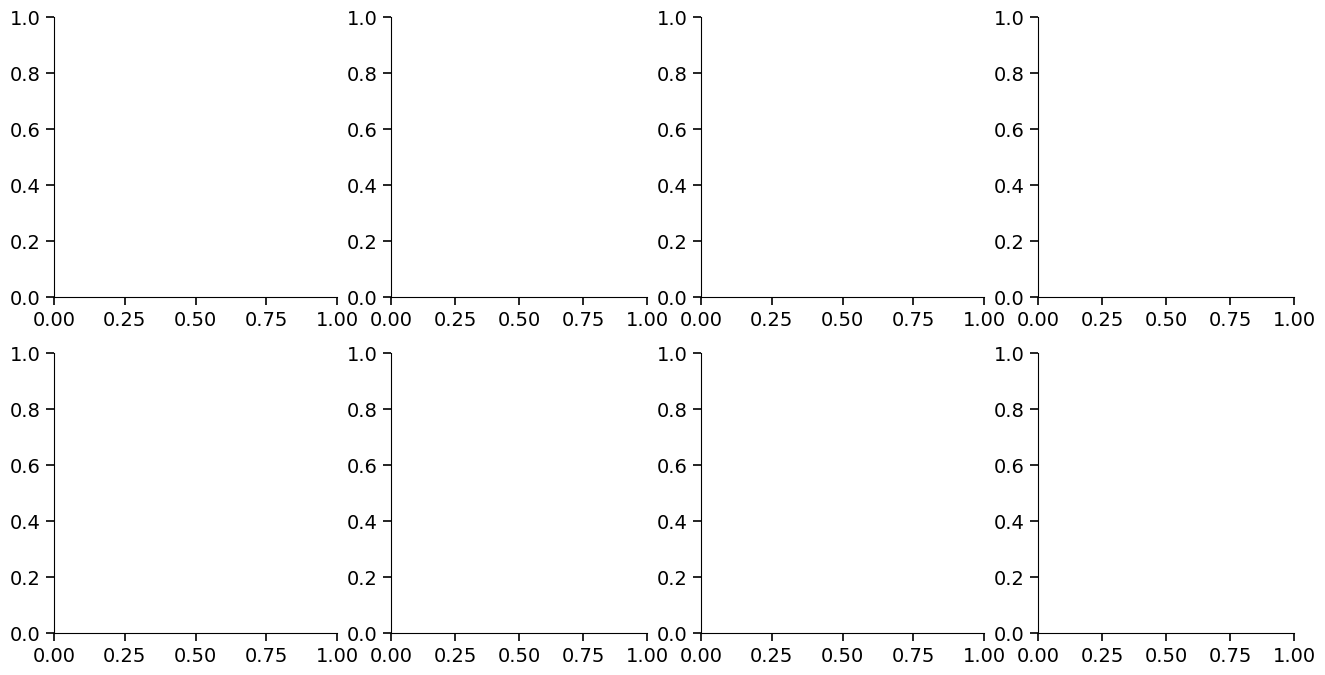

In [9]:
plot_all_vars_per_quartile(var_disp_list)